<h3>Title and Objective</h3>

In [ ]:
# Phishing Website Detection - Final Model Evaluation and Validation
# Objective: The objective of this phase is to evaluate the final saved machine learning model on unseen data, measure its performance using classification metrics, compare training and testing accuracy to check overfitting or underfitting, and confirm that the model is ready for final use.

<h3>Import Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import joblib

<h3>Load Saved Train/Test Files</h3>

In [2]:
X_train = pd.read_csv("../data/X_train_scaled.csv")
X_test = pd.read_csv("../data/X_test_scaled.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (69767, 111)
X_test shape: (17442, 111)
y_train shape: (69767,)
y_test shape: (17442,)


<h3>Load Saved Model and Scalar</h3>

In [3]:
rf = joblib.load("../models/phishing_rf_model.pkl")
scaler = joblib.load("../models/phishing_scaler.pkl")

<h3>Make Final Predictions</h3>

In [4]:
y_pred_test = rf.predict(X_test)
y_prob_test = rf.predict_proba(X_test)[:, 1]

y_pred_train = rf.predict(X_train)

<h3>Compute Evaluation Metrics</h3>

In [5]:
print("Final Test Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1 Score:", f1_score(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))
print(classification_report(y_test, y_pred_test))

Final Test Evaluation
Accuracy: 0.9700722394220846
Precision: 0.9554140127388535
Recall: 0.9591736350221348
F1 Score: 0.9572901325478645
ROC-AUC: 0.9950494252341725
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11343
           1       0.96      0.96      0.96      6099

    accuracy                           0.97     17442
   macro avg       0.97      0.97      0.97     17442
weighted avg       0.97      0.97      0.97     17442



<h3>Plot Confusion Matrix</h3>

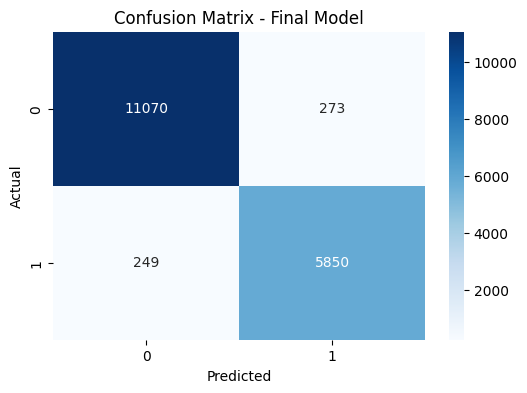

In [6]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h3>Plot ROC Curve</h3>

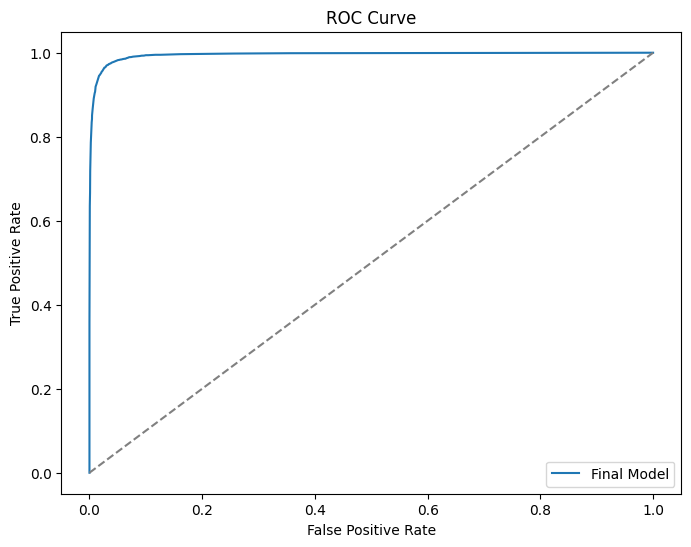

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Final Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<h3>Check Overfitting or Underfitting</h3>

In [ ]:
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)


Train Accuracy: 0.9999283328794416
Test Accuracy: 0.9700722394220846
Accuracy Gap: 0.029856093457356958


<h3>Final Evaluation Summary</h3>

In [9]:
print("Final Model Evaluation Summary")
print("--------------------------------")
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1 Score:", f1_score(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))

Final Model Evaluation Summary
--------------------------------
Train Accuracy: 0.9999283328794416
Test Accuracy: 0.9700722394220846
Precision: 0.9554140127388535
Recall: 0.9591736350221348
F1 Score: 0.9572901325478645
ROC-AUC: 0.9950494252341725


## Final Model Evaluation and Validation

- The final saved phishing detection model was loaded and tested on unseen data.
- Accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix were used for evaluation.
- Train and test accuracy were compared to check overfitting or underfitting.
- ROC curve was plotted to visualize classification performance.
- The model was validated as ready for final use.